## Импорты и константы

In [28]:
from pathlib import Path
import pandas as pd
import torch
from torch import nn, optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets
from PIL import Image
import torchvision.models as models
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
import numpy as np

RANDOM_STATE = 42
DATA_DIR = Path("../data")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"


## Трансформации

In [29]:
# Статистики ImageNet для нормализации
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# === TRAIN: аугментации и подготовка
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    # сохраняет мелкие детали (крошки, пятна), но дает модели видеть тарелку под разными углами и масштабами
    transforms.RandomHorizontalFlip(p=0.5),  # ломаем ориентацию узора
    transforms.RandomVerticalFlip(p=0.5),
    
    # transforms.RandomRotation(degrees=45),  # поворот заменить на RandomAffine для более естественных искажений
    transforms.RandomAffine(
        degrees=45,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=10,
        fill=0
    ),
    transforms.ColorJitter(  # Освещение (блики)
        brightness=0.3,  # ±30% яркости
        contrast=0.3,  # ±30% контраста
        saturation=0.3,  # ±30% насыщенности
        hue=0.05  # лёгкий сдвиг оттенка
    ),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))     #Blur (заблюренный фон)  
    ], p=0.05),  # шанс применения, лучше маленький, не размоет грязь на тарелках
    
    transforms.ToTensor(),  # обеспечивает правильный формат тензоров [batch_size, каналы(RGB), высота, ширина]
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),  # нормализация
])

# === VAL/TEST: только подготовка (без аугментаций)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

## Dataset для обучения

In [30]:
# torchvision.datasets.ImageFolder автоматически понимает структуру папок:
# data/train/cleaned -> класс 0
# data/train/dirty   -> класс 1
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)

# Смотрим, какие классы он нашел и какие индексы им присвоил
print("Классы:", train_dataset.classes)  # Ожидаем: ['cleaned', 'dirty']
print("Маппинг классов:", train_dataset.class_to_idx)  # Ожидаем: {'cleaned': 0, 'dirty': 1}

Классы: ['cleaned', 'dirty']
Маппинг классов: {'cleaned': 0, 'dirty': 1}


## Кастомный Dataset для теста

In [31]:
class TestImageDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        # Читаем submission CSV, чтобы знать порядок ID и общее количество
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Получаем ID и гарантируем формат с ведущими нулями (например, "0005")
        raw_id = self.df.iloc[idx]['id']
        img_id = str(raw_id).zfill(4)

        # 2. Формируем путь с помощью pathlib (оператор /)
        img_path = self.img_dir / f"{img_id}.jpg"

        # 3. Загружаем изображение
        try:
            image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            raise FileNotFoundError(f"Изображение не найдено: {img_path}. Проверьте пути и имена файлов.")

        # 4. Применяем трансформации
        if self.transform:
            image = self.transform(image)

        # 5. Возвращаем тензор и строковый ID (метку не возвращаем, мы её предсказываем)
        return image, img_id


## Маленькая классическая CNN 
3 блока сверток(Conv2D, BatchNorm, RELU, MaxPooling) + Dense (Linear, RELU, Dropout, Linear)

In [32]:
class SimplePlateCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimplePlateCNN, self).__init__()

        # Блок 1: Извлекаем базовые признаки (края, цвета)
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),  # 224x224 -> 224x224
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 224x224 -> 112x112

            # Блок 2: Извлекаем текстуры (пятна, узоры)
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 112x112 -> 56x56

            # Блок 3: Извлекаем более сложные паттерны (крошки, специфичная грязь)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 56x56 -> 28x28
        )

        # AdaptiveAvgPool2d гарантирует, что на вход классификатора 
        # всегда придет тензор фиксированного размера, независимо от входа.
        # Это также сильно уменьшает количество параметров!
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))  # 32 x 7 x 7 = 1568 признаков

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Dropout(p=0.7),  # регуляризация
            nn.Linear(64, num_classes)  # Выход: сырые логиты (без Softmax!)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

### Цикл обучения


In [33]:
def train_model_with_early_stopping(model, train_loader, val_loader, criterion, optimizer,
                                    epochs, device, save_path="best_model.pth",
                                    scheduler=None, patience=5, verbose=False):
    """Обучение с Early Stopping (минимум логов)."""
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    best_val_loss = float('inf')
    epochs_without_improvement = 0

    for epoch in range(epochs):
        # ФАЗА ОБУЧЕНИЯ
        model.train()
        running_train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        epoch_train_loss = running_train_loss / train_total
        epoch_train_acc = train_correct / train_total

        # ФАЗА ВАЛИДАЦИИ
        model.eval()
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / val_total
        epoch_val_acc = val_correct / val_total

        if scheduler is not None:
            scheduler.step(epoch_val_loss)

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        # Печатаем только если verbose=True или каждые 5 эпох
        if verbose or (epoch + 1) % 5 == 0:
            print(
                f"  Epoch {epoch + 1:02d} | Train: {epoch_train_loss:.4f}/{epoch_train_acc:.4f} | Val: {epoch_val_loss:.4f}/{epoch_val_acc:.4f}",
                flush=True)

        # Early Stopping
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print(f"  ⏹ Early Stopping на эпохе {epoch + 1}", flush=True)
            break

    model.load_state_dict(torch.load(save_path))
    return model, history

### Функция для отрисовки графиков обучения

In [34]:

def plot_training_history(history):
    """Строит графики Loss и Accuracy для тренировочной и валидационной выборок."""

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    # LOSS
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-o', label='Val Loss', linewidth=2, markersize=6)

    axes[0].set_title('Model Loss (Cross-Entropy)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # ACCURACY
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-o', label='Val Accuracy', linewidth=2, markersize=6)

    axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

### Настройка обучения


Fold 1/5
  Epoch 05 | Train: 0.8434/0.4062 | Val: 0.6847/0.6250
  Epoch 10 | Train: 0.7609/0.4688 | Val: 0.7246/0.2500
  Best Val Acc: 0.8750

Fold 2/5
  Epoch 05 | Train: 0.7165/0.5938 | Val: 0.6932/0.6250
  Best Val Acc: 0.6250

Fold 3/5
  Epoch 05 | Train: 0.7017/0.5625 | Val: 0.7330/0.2500
  Epoch 10 | Train: 0.6062/0.8125 | Val: 0.6459/0.6250
  Best Val Acc: 0.7500

Fold 4/5
  Epoch 05 | Train: 0.8150/0.4062 | Val: 0.6619/0.7500
  Epoch 10 | Train: 0.6298/0.6250 | Val: 0.7295/0.3750
  Best Val Acc: 0.7500

Fold 5/5
  Epoch 05 | Train: 0.6917/0.4688 | Val: 0.6935/0.6250
  Epoch 10 | Train: 0.7060/0.5000 | Val: 0.6851/0.5000
  Best Val Acc: 0.7500


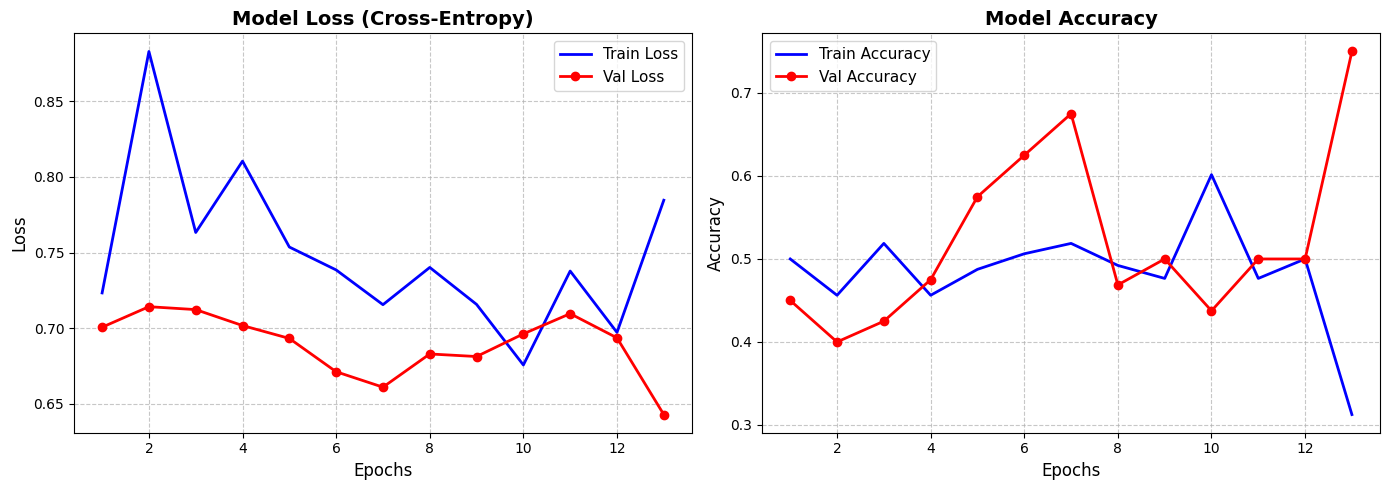


Средняя Val Accuracy: 0.7500 ± 0.0791
Финальное обучение на всех 40 изображениях...
     Epoch 01 | Loss: 0.7668 | Acc: 0.4750 [СОХРАНЕНО]
     Epoch 02 | Loss: 0.7770 | Acc: 0.5750
     Epoch 03 | Loss: 0.8394 | Acc: 0.3500
     Epoch 04 | Loss: 0.7079 | Acc: 0.5750 [СОХРАНЕНО]
     Epoch 05 | Loss: 0.9403 | Acc: 0.3750
     Epoch 06 | Loss: 0.7593 | Acc: 0.5250
     Epoch 07 | Loss: 0.7686 | Acc: 0.4250
     Epoch 08 | Loss: 0.6962 | Acc: 0.5750 [СОХРАНЕНО]
     Epoch 09 | Loss: 0.7572 | Acc: 0.5750
     Epoch 10 | Loss: 0.6984 | Acc: 0.6750
     Epoch 11 | Loss: 0.6502 | Acc: 0.6000 [СОХРАНЕНО]
     Epoch 12 | Loss: 0.7619 | Acc: 0.4250
     Epoch 13 | Loss: 0.7138 | Acc: 0.6250
     Epoch 14 | Loss: 0.6750 | Acc: 0.6250
     Epoch 15 | Loss: 0.7137 | Acc: 0.5500
     Epoch 16 | Loss: 0.6844 | Acc: 0.5250
     Epoch 17 | Loss: 0.7424 | Acc: 0.5000
     Epoch 18 | Loss: 0.7493 | Acc: 0.4250
     Epoch 19 | Loss: 0.6864 | Acc: 0.6000
     Epoch 20 | Loss: 0.6739 | Acc: 0.5750
     Ep

In [35]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu")
LEARNING_RATE = 5e-4
REGULARIZATION = 1e-3
BATCH_SIZE = 8
NUM_EPOCHS = 30
N_FOLDS = 5

full_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)

# K-FOLD CROSS-VALIDATION
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Для усреднённого графика: списки по эпохам
fold_histories = []
fold_best_accs = []

for fold, (train_idx, val_idx) in enumerate(kf.split(range(len(full_dataset)))):
    print(f"\nFold {fold + 1}/{N_FOLDS}")

    train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)

    model = SimplePlateCNN(num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=REGULARIZATION)

    # Scheduler для стабилизации обучения
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)
    # Обучаем
    _, history = train_model_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=50,  # early stopping остановит раньше
        device=device,
        save_path=f"model_fold{fold + 1}.pth",
        scheduler=scheduler,
        patience=5  # Останавливаемся после 5 эпох без улучшения val loss
    )
    fold_histories.append(history)
    fold_best_accs.append(max(history['val_acc']))
    print(f"  Best Val Acc: {max(history['val_acc']):.4f}")

# Находим максимальное количество эпох, до которого дошло хоть одно обучение
max_epochs = max(len(h['train_loss']) for h in fold_histories)

# Усредняем историю, учитывая разную длину списков
avg_history = {}
for k in ['train_loss', 'train_acc', 'val_loss', 'val_acc']:
    avg_history[k] = []
    for i in range(max_epochs):
        # Берем значения только из тех fold'ов, которые дошли до эпохи i
        values = [h[k][i] for h in fold_histories if i < len(h[k])]
        avg_history[k].append(np.mean(values))

# Рисуем график
plot_training_history(avg_history)
print(f"\nСредняя Val Accuracy: {np.mean(fold_best_accs):.4f} ± {np.std(fold_best_accs):.4f}")

# Финальная модель на всех данных
final_model = SimplePlateCNN(num_classes=2).to(device)
final_optimizer = optim.AdamW(final_model.parameters(), lr=LEARNING_RATE, weight_decay=REGULARIZATION)
final_scheduler = optim.lr_scheduler.ReduceLROnPlateau(final_optimizer, mode='min', factor=0.5, patience=3)
final_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Финальное обучение на всех 40 изображениях...")
best_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    final_model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in final_loader:
        images, labels = images.to(device), labels.to(device)
        final_optimizer.zero_grad()
        outputs = final_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        final_optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    final_scheduler.step(epoch_loss)
    
    # СОХРАНЯЕМ ЛУЧШУЮ МОДЕЛЬ (по train loss)
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(final_model.state_dict(), "final_model.pth")
        print(f"     Epoch {epoch+1:02d} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} [СОХРАНЕНО]")
    else:
        print(f"     Epoch {epoch+1:02d} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")
    
    # 👇 ДОПОЛНИТЕЛЬНО: сохраняем чекпоинт каждые 5 эпох
    if (epoch + 1) % 5 == 0:
        torch.save(final_model.state_dict(), f"final_model_epoch{epoch+1}.pth")

print("Финальная модель сохранена: final_model.pth")
print(f"Лучший Train Loss: {best_loss:.4f}")

### Выводы по Baseline 

Val Loss плавно снижается (0.70 → 0.64) — это главный признак, что модель обобщает, а не переобучается

Val Accuracy растет (до 0.67 на epoch 7, потом скачет, но в конце 0.75) — модель учится распознавать паттерны.

Early Stopping сработал на epoch 13 — модель остановилась, когда Val Loss перестал улучшаться (на epoch 8).

Проблемы:
Train Accuracy низкая (~0.5) — модель недообучается на тренировочных данных.
Разрыв Train/Val Accuracy — Val Accuracy выше Train (0.75 vs 0.5), что нетипично.

Возможные причины:

Случайность: в батче из 8 изображениях одна ошибка = ±12.5% accuracy.

Аугментации: Train данные сильно искажены (RandomResizedCrop, ColorJitter), а Val — нет. Модель видит "чистые" картинки на валидации и справляется лучше.

Dropout: на train он активен (выключает 70% нейронов), на val — отключен.

## Transfer Learning

In [36]:
# Загружаем предобученный ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Замораживаем всё, кроме последнего слоя
for param in model.parameters():
    param.requires_grad = False

# Заменяем классификатор
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 2)
)

model = model.to(device)
optimizer = optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-3)